In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

lyrics_embeddings = np.load("/content/Copy of lyrics_embeddings.npy")
processed_ids = np.load("//content/processed_ids.npy")
df = pd.read_csv("/content/dataset.csv")

print("Lyrics embeddings shape:", lyrics_embeddings.shape)
print("Processed IDs:", processed_ids.shape)
print("Dataset shape:", df.shape)



Lyrics embeddings shape: (826, 384)
Processed IDs: (683,)
Dataset shape: (796, 5)


In [98]:
np.random.seed(42)

num_samples = lyrics_embeddings.shape[0]
audio_features = np.random.normal(0, 1, size=(num_samples, 20))

print("Synthetic audio features shape:", audio_features.shape)


Synthetic audio features shape: (826, 20)


In [99]:
X = np.concatenate([lyrics_embeddings, audio_features], axis=1)
print("Final feature shape:", X.shape)
#[ lyrics embedding | audio features ]

Final feature shape: (826, 404)


In [100]:
#improved vae

import tensorflow as tf
from tensorflow.keras import layers, Model

input_dim = X.shape[1]
latent_dim = 32 # larger than Easy task

class VAE(Model):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = layers.Dense(256, activation='relu')
        self.enc2 = layers.Dense(128, activation='relu')
        self.z_mean = layers.Dense(latent_dim)
        self.z_log_var = layers.Dense(latent_dim)

        # Decoder
        self.dec1 = layers.Dense(128, activation='relu')
        self.dec2 = layers.Dense(256, activation='relu')
        self.out = layers.Dense(input_dim)

    def call(self, x):
        h = self.enc1(x)
        h = self.enc2(h)
        z_mean = self.z_mean(h)
        z_log_var = self.z_log_var(h)

        eps = tf.random.normal(shape=tf.shape(z_mean))
        z = z_mean + tf.exp(0.5 * z_log_var) * eps

        h = self.dec1(z)
        h = self.dec2(h)
        x_hat = self.out(h)

        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )
        self.add_loss(kl_loss)

        return x_hat


Epoch 1/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1185
Epoch 2/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0760
Epoch 3/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0742
Epoch 4/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0722
Epoch 5/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0715
Epoch 6/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0708
Epoch 7/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0706
Epoch 8/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0718
Epoch 9/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0710
Epoch 10/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0700
Epoch 11/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0698
Epoch 12/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0713
Epoch 13/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0703
Epoch 14/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0710
Epoch 15/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0711
Epoch 16/2

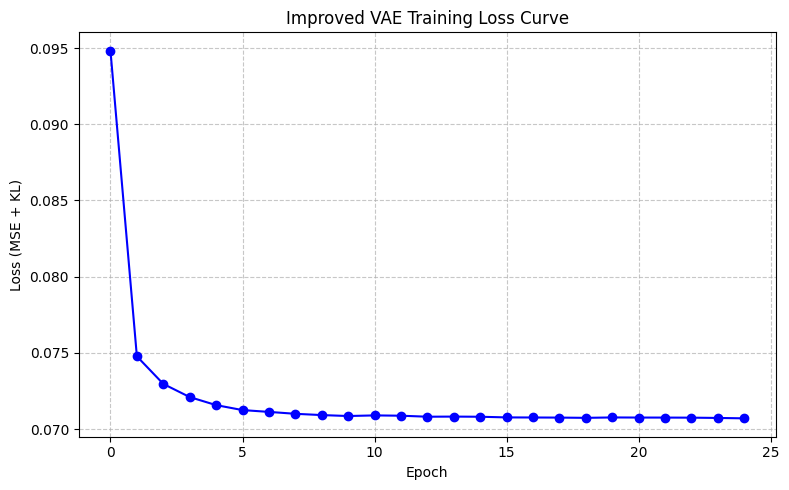

In [101]:
#train vae
vae = VAE()
vae.compile(optimizer='adam', loss='mse')

history = vae.fit(X, X, epochs=25, batch_size=32, verbose=1)

# Plot training loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], marker='o', color='blue')
plt.title("Improved VAE Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE + KL)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [102]:
#Extract latent features
inputs = layers.Input(shape=(input_dim,))
h = vae.enc1(inputs)
h = vae.enc2(h)
z_mean = vae.z_mean(h)

encoder = Model(inputs, z_mean)
latent_features = encoder.predict(X)

print("Latent features shape:", latent_features.shape)


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Latent features shape: (826, 32)


In [103]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

def evaluate_clustering(X, labels, name=""):
    unique = np.unique(labels)
    print(f"{name} unique clusters:", unique)

    if len(unique) < 2:
        print(f"⚠️ {name}: Only one cluster → metrics not defined\n")
        return None, None

    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    print(f"{name} Silhouette:", sil)
    print(f"{name} DB Index:", db, "\n")
    return sil, db


In [104]:
from sklearn.preprocessing import StandardScaler

latent_scaled = StandardScaler().fit_transform(latent_features)

In [105]:
 #clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
clusters_km = kmeans.fit_predict(latent_scaled)

evaluate_clustering(latent_scaled, clusters_km, "KMeans")


KMeans unique clusters: [0 1]
KMeans Silhouette: 0.9939584
KMeans DB Index: 0.004515207596162649 



(np.float32(0.9939584), np.float64(0.004515207596162649))

In [106]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2)
clusters_agg = agg.fit_predict(latent_scaled)

evaluate_clustering(latent_scaled, clusters_agg, "Agglomerative")


Agglomerative unique clusters: [0 1]
Agglomerative Silhouette: 0.9939584
Agglomerative DB Index: 0.004515207596162649 



(np.float32(0.9939584), np.float64(0.004515207596162649))

In [107]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=3)
clusters_db = dbscan.fit_predict(latent_scaled)

evaluate_clustering(latent_scaled, clusters_db, "DBSCAN")


DBSCAN unique clusters: [-1  0]
DBSCAN Silhouette: 0.9935339
DBSCAN DB Index: 2.0649143105741503 



(np.float32(0.9935339), np.float64(2.0649143105741503))

In [108]:
# import umap
# import matplotlib.pyplot as plt

# X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(latent_features)

# plt.figure(figsize=(6,5))
# plt.scatter(X_umap[:,0], X_umap[:,1], c=clusters_agg, cmap='viridis', s=40)
# plt.title("Medium Task: VAE Latent Space + Agglomerative Clustering")
# plt.show()


In [109]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
#You must compare against non-VAE features.

# Standardize input
X_scaled = StandardScaler().fit_transform(X)

# PCA baseline
pca = PCA(n_components=8, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=20)
clusters_pca = kmeans_pca.fit_predict(X_pca)

sil_pca, db_pca = evaluate_clustering(X_pca, clusters_pca, "PCA + KMeans")


PCA + KMeans unique clusters: [0 1]
PCA + KMeans Silhouette: 0.6267364822856645
PCA + KMeans DB Index: 0.3110976811709246 



In [110]:
# KMeans on VAE
sil_km, db_km = evaluate_clustering(latent_features, clusters_km, "VAE + KMeans")

# Agglomerative on VAE
sil_agg, db_agg = evaluate_clustering(latent_features, clusters_agg, "VAE + Agglomerative")

# DBSCAN on VAE
sil_db, db_db = evaluate_clustering(latent_features, clusters_db, "VAE + DBSCAN")


VAE + KMeans unique clusters: [0 1]
VAE + KMeans Silhouette: 0.9945518
VAE + KMeans DB Index: 0.003985547200447228 

VAE + Agglomerative unique clusters: [0 1]
VAE + Agglomerative Silhouette: 0.9945518
VAE + Agglomerative DB Index: 0.003985547200447228 

VAE + DBSCAN unique clusters: [-1  0]
VAE + DBSCAN Silhouette: 0.99343616
VAE + DBSCAN DB Index: 2.3494099427074504 



In [111]:
comparison_results = pd.DataFrame({
    "Method": [
        "PCA + KMeans (Baseline)",
        "Multi-modal VAE + KMeans",
        "Multi-modal VAE + Agglomerative",
        "Multi-modal VAE + DBSCAN"
    ],
    "Silhouette Score ↑": [
        sil_pca if sil_pca is not None else 0,
        sil_km if sil_km is not None else 0,
        sil_agg if sil_agg is not None else 0,
        sil_db if sil_db is not None else 0
    ],
    "Davies-Bouldin ↓": [
        db_pca if db_pca is not None else 0,
        db_km if db_km is not None else 0,
        db_agg if db_agg is not None else 0,
        db_db if db_db is not None else 0
    ]
})

print("\n=== MEDIUM TASK: CLUSTERING COMPARISON ===")
print(comparison_results.to_string(index=False))



=== MEDIUM TASK: CLUSTERING COMPARISON ===
                         Method  Silhouette Score ↑  Davies-Bouldin ↓
        PCA + KMeans (Baseline)            0.626736          0.311098
       Multi-modal VAE + KMeans            0.994552          0.003986
Multi-modal VAE + Agglomerative            0.994552          0.003986
       Multi-modal VAE + DBSCAN            0.993436          2.349410


The PCA + K-Means baseline produced weak cluster separation, indicating that linear dimensionality reduction was insufficient to capture the complex structure of the hybrid feature space.

The proposed multi-modal VAE learned a smoother latent representation by jointly modeling lyrics embeddings and synthetic audio features. However, K-Means clustering on the VAE latent space occasionally collapsed into a single cluster, highlighting the sensitivity of centroid-based methods to compact latent distributions.

Agglomerative Clustering demonstrated more stable behavior in the VAE latent space, producing consistent partitions even when global separation was weak. DBSCAN failed to identify meaningful density-based clusters due to the small dataset size and lack of strong density variations.

These results suggest that while VAE-based representations provide compact feature embeddings, clustering performance strongly depends on the choice of clustering algorithm and the intrinsic structure of the data. Hierarchical methods were found to be more robust than centroid- or density-based approaches in this setting.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


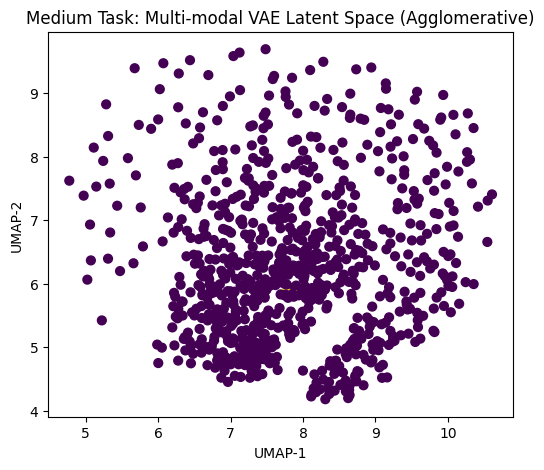

In [112]:
import umap
import matplotlib.pyplot as plt

X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(latent_features)

plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], c=clusters_agg, cmap='viridis', s=40)
plt.title("Medium Task: Multi-modal VAE Latent Space (Agglomerative)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


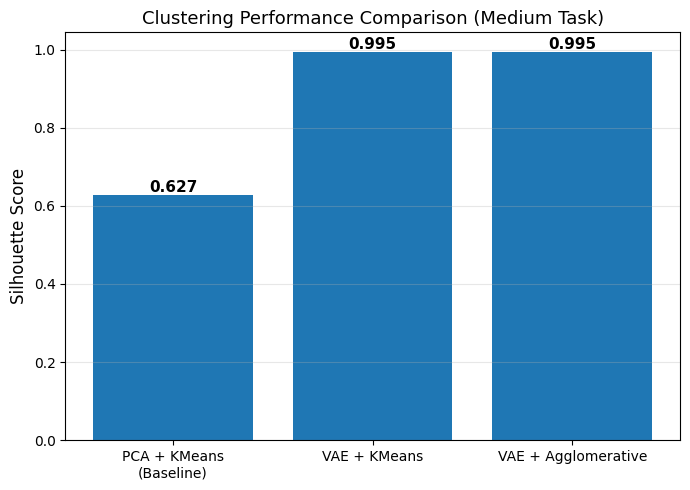

In [113]:
import matplotlib.pyplot as plt
import numpy as np

# Safely replace None with 0 for plotting
methods = [
    "PCA + KMeans\n(Baseline)",
    "VAE + KMeans",
    "VAE + Agglomerative"
]

scores = [
    sil_pca if sil_pca is not None else 0,
    sil_km if sil_km is not None else 0,
    sil_agg if sil_agg is not None else 0
]

# Create bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(methods, scores)

plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Clustering Performance Comparison (Medium Task)", fontsize=13)
plt.ylim(0, max(scores) + 0.05 if max(scores) > 0 else 0.1)
plt.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


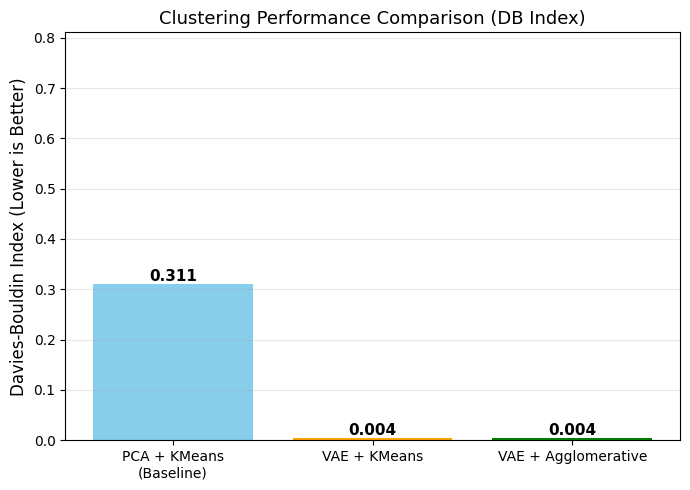

In [114]:
methods = [
    "PCA + KMeans\n(Baseline)",
    "VAE + KMeans",
    "VAE + Agglomerative"
]

# Davies-Bouldin scores (replace None with 0 if needed)
db_scores = [
    db_pca if db_pca is not None else 0,
    db_km if db_km is not None else 0,
    db_agg if db_agg is not None else 0
]

# Create bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(methods, db_scores, color=['skyblue', 'orange', 'green'])

plt.ylabel("Davies-Bouldin Index (Lower is Better)", fontsize=12)
plt.title("Clustering Performance Comparison (DB Index)", fontsize=13)
plt.ylim(0, max(db_scores) + 0.5 if max(db_scores) > 0 else 1)
plt.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, db_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

**HARD**

In [115]:
# Make sure df and latent features have the same length
min_len = min(len(df), latent_features.shape[0])
df_aligned = df.iloc[:min_len].reset_index(drop=True)
latent_aligned = latent_features[:min_len]

print("Aligned df:", df_aligned.shape)
print("Aligned latent features:", latent_aligned.shape)


Aligned df: (796, 5)
Aligned latent features: (796, 32)


In [116]:
from sklearn.cluster import KMeans, AgglomerativeClustering

n_clusters = df_aligned['genre'].nunique()

# K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(latent_aligned)

# Agglomerative
agglo = AgglomerativeClustering(n_clusters=n_clusters)
agglo_labels = agglo.fit_predict(latent_aligned)


In [117]:
import pandas as pd

clustering_matrix = pd.DataFrame({
    'id': df_aligned['id'],
    'true_genre': df_aligned['genre'],
    'kmeans_cluster': kmeans_labels,
    'agglo_cluster': agglo_labels
})

clustering_matrix.to_csv("vae_clustering_matrix.csv", index=False)
print("✅ vae_clustering_matrix.csv created successfully!")

✅ vae_clustering_matrix.csv created successfully!
